In [55]:
# ~~ Jupyter notebook containing useful functions for loading hst data ~~~

In [1]:
import os

def get_immediate_subfolders(parent_folder):
    """Returns a list of immediate subfolders in the parent folder."""
    return [
        os.path.join(parent_folder, name)
        for name in os.listdir(parent_folder)
        if os.path.isdir(os.path.join(parent_folder, name))
    ]

def get_filenames(folder):
    """Returns all filenames (not full paths) in a folder."""
    return [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]

def extract_substrings(filename, split_chars=None):
    """Split filename into substrings based on delimiters."""
    base = os.path.splitext(filename)[0]  # Remove file extension
    if split_chars is None:
        split_chars = ['_', '-', '.']
    for ch in split_chars:
        base = base.replace(ch, ' ')
    return set(base.split())

def common_substrings_in_child_folders(top_folder):
    subfolders = get_immediate_subfolders(top_folder)
    if not subfolders:
        print("No subfolders found.")
        return set()

    all_folder_substrings = []

    for folder in subfolders:
        filenames = get_filenames(folder)
        substrings = set()
        for fname in filenames:
            substrings.update(extract_substrings(fname))
        if substrings:
            all_folder_substrings.append(substrings)

    if not all_folder_substrings:
        print("No filenames found in any subfolders.")
        return set()

    return set.intersection(*all_folder_substrings)


In [2]:
# Example usage
top_folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST"
common = common_substrings_in_child_folders(top_folder)

print("Common substrings found in filenames across all subfolders:")
for s in sorted(common):
    print(s)

Common substrings found in filenames across all subfolders:
d4477c
drz
e4c98e
flt
hlet
jif
jit
log
raw
spt
trl


In [4]:
import os
import shutil

def copy_files_with_suffix(top_folder, output_folder, suffix):
    # Make sure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Get all subfolders
    subfolders = [
        os.path.join(top_folder, name)
        for name in os.listdir(top_folder)
        if os.path.isdir(os.path.join(top_folder, name))
    ]

    count = 0
    for folder in subfolders:
        for fname in os.listdir(folder):
            if fname.endswith(suffix):
                src_path = os.path.join(folder, fname)
                dst_path = os.path.join(output_folder, fname)

                # Optional: avoid name collisions by prefixing folder name
                if os.path.exists(dst_path):
                    folder_name = os.path.basename(folder)
                    dst_path = os.path.join(output_folder, f"{folder_name}_{fname}")

                shutil.copy2(src_path, dst_path)
                count += 1

    print(f"Copied {count} files with suffix '{suffix}' to '{output_folder}'.")

# Example usage
top_folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-07-04T1545/MAST_2025-07-04T1545/WFC3PSF/"
output_folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-07-04T1545/MAST_2025-07-04T1545/WFC3PSF/flc/"
suffix = "flc_cutout.fits"  

copy_files_with_suffix(top_folder, output_folder, suffix)


Copied 0 files with suffix 'flc_cutout.fits' to '/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-07-04T1545/MAST_2025-07-04T1545/WFC3PSF/flt'.


In [5]:
import os
import shutil
from astropy.io import fits

def extract_photmode_key(header):
    """
    Extract 'UVIS2 F657N' from 'WFC3 UVIS2 F657N MJD#59463.8882'
    """
    photmode = header.get('PHOTMODE', None)
    if photmode is None:
        return None
    parts = photmode.split()
    if len(parts) < 3:
        return None
    return f"{parts[1]} {parts[2]}"

def organize_fits_by_photmode(folder):
    fits_files = [f for f in os.listdir(folder) if f.lower().endswith('.fits')]

    for fname in fits_files:
        fpath = os.path.join(folder, fname)
        try:
            with fits.open(fpath, memmap=True) as hdul:
                header = hdul[1].header
                mode = extract_photmode_key(header)

            if mode:
                target_dir = os.path.join(folder, mode)
                os.makedirs(target_dir, exist_ok=True)

                dst_path = os.path.join(target_dir, fname)
                shutil.move(fpath, dst_path)
                print(f"Moved {fname} -> {target_dir}")
            else:
                print(f"{fname}: 'PHOTMODE' not found or malformed")

        except Exception as e:
            print(f"{fname}: Error - {e}")

# Example usage
organize_fits_by_photmode(output_folder)


Moved ieaq23daq_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F845M
Moved ieaq28leq_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F467M
Moved ieaq28l8q_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F845M
Moved ieaq22cdq_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F547M
Moved ieaq25g1q_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS1 FQ619N
Moved ieaq28l9q_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F467M
Moved ieaq22cmq_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 FQ727N
Moved ieaq23ddq_flt.fits -> /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F657N
Moved ieaq24ea

Filename: /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/drz/UVIS1 FQ619N/ieaq22cnq_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     800   ()      
  1  SCI           1 ImageHDU        86   (2043, 2164)   float32   
  2  WHT           1 ImageHDU        45   (2043, 2164)   float32   
  3  CTX           1 ImageHDU        40   (2043, 2164)   int32   
  4  HDRTAB        1 BinTableHDU    561   1R x 276C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 13A, 4A, 1A, 4A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 19A, 1A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 20A, 9A, 8A, D, D, 4A, 18A, 3A, K, 6A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D

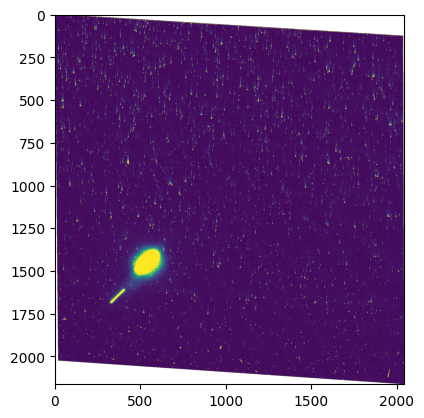

In [19]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

output_folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/drz/"

with fits.open(output_folder + "UVIS1 FQ619N/ieaq22cnq_drz.fits") as hdu:
    fits.info(output_folder + "UVIS1 FQ619N/ieaq22cnq_drz.fits")
    data = hdu[1].data
    header = hdu[0].header

print(np.nanmin(data), np.nanmax(data), np.nanmedian(data))
plt.imshow(data, vmin=0, vmax=np.nanpercentile(data, 99))

In [1]:
import os
from astropy.io import fits
from telescope_reduction import *

# Example usage
folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/drz/UVIS2 F547M"
print_head_entry_fits(folder, 'EXPTIME', header_hdu=0)


ieaq26j2q_drz.fits: 6.0
ieaq24edq_drz.fits: 6.0
ieaq26j7q_drz.fits: 6.0
ieaq28laq_drz.fits: 6.0
ieaq27kcq_drz.fits: 6.0
ieaq25fqq_drz.fits: 6.0
ieaq23dhq_drz.fits: 6.0
ieaq25fvq_drz.fits: 6.0
ieaq28lfq_drz.fits: 6.0
ieaq23dcq_drz.fits: 6.0
ieaq27k7q_drz.fits: 6.0
ieaq22cdq_drz.fits: 6.0
ieaq22ciq_drz.fits: 6.0
ieaq24e8q_drz.fits: 6.0


/.n--- ieaq25ftq_drz.fits ---


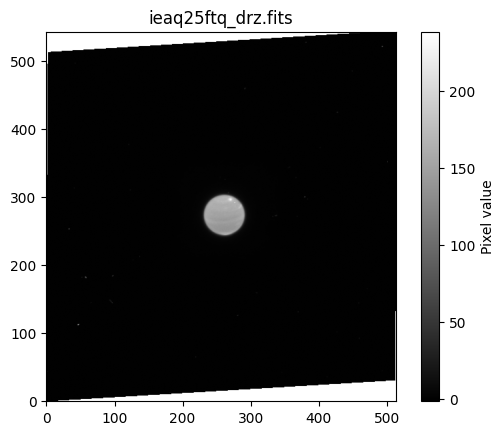

/.n--- ieaq24e6q_drz.fits ---


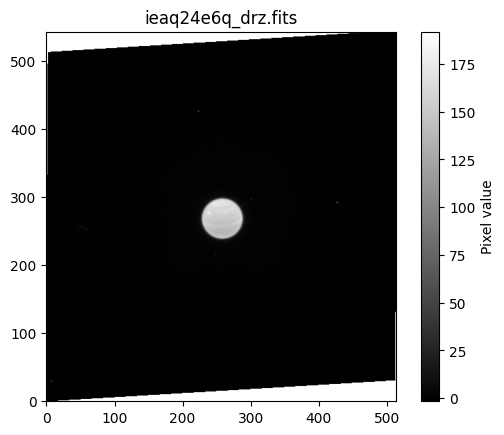

/.n--- ieaq23daq_drz.fits ---


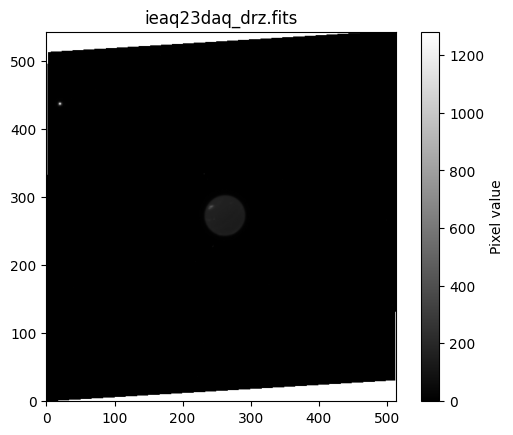

/.n--- ieaq28l8q_drz.fits ---


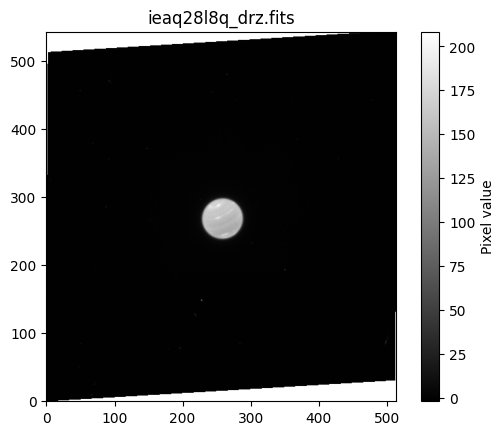

/.n--- ieaq27kaq_drz.fits ---


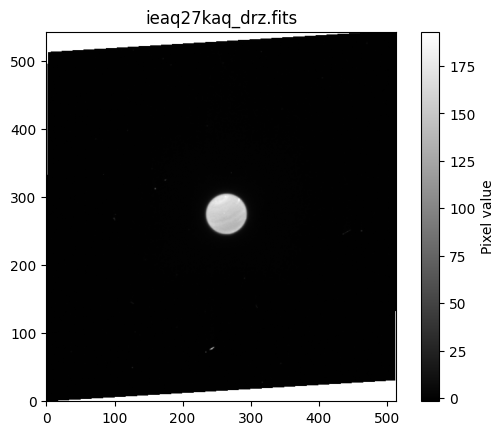

/.n--- ieaq25foq_drz.fits ---


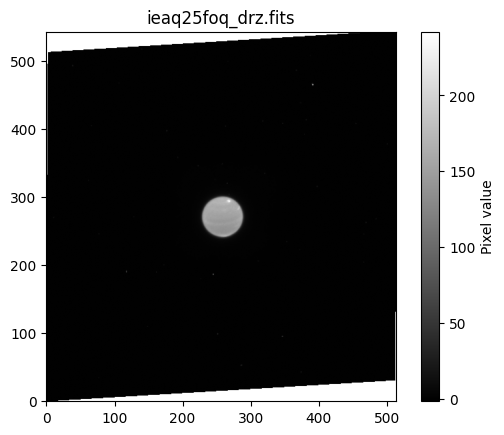

/.n--- ieaq28ldq_drz.fits ---


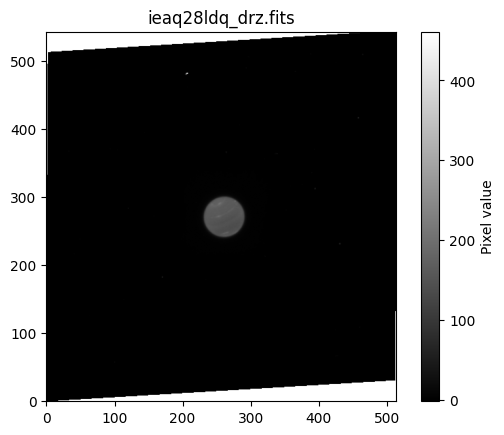

/.n--- ieaq23dfq_drz.fits ---


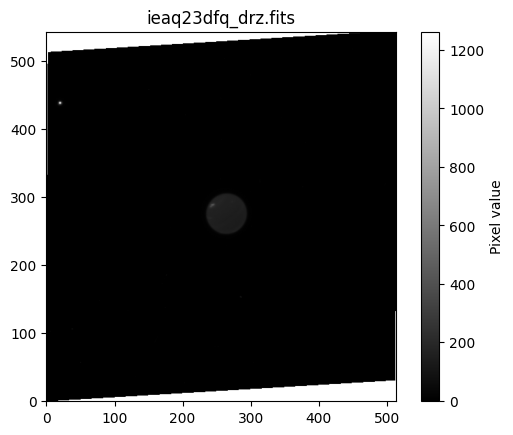

/.n--- ieaq24ebq_drz.fits ---


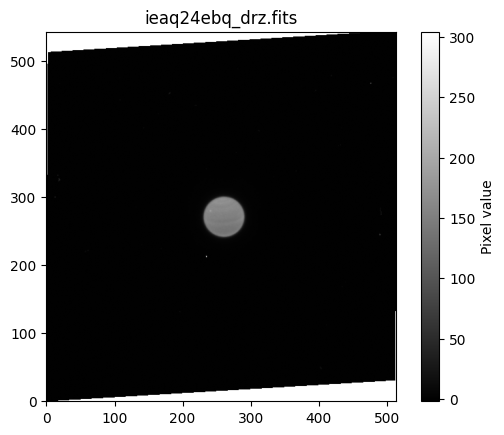

/.n--- ieaq26j0q_drz.fits ---


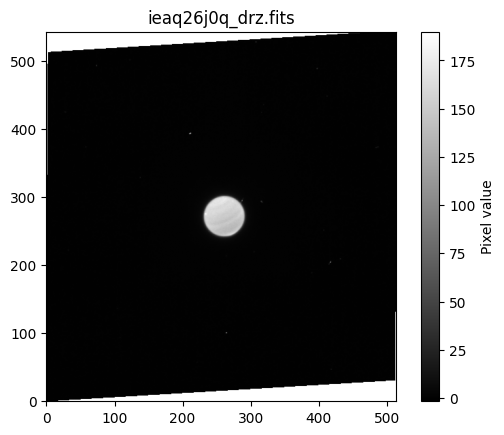

/.n--- ieaq22cbq_drz.fits ---


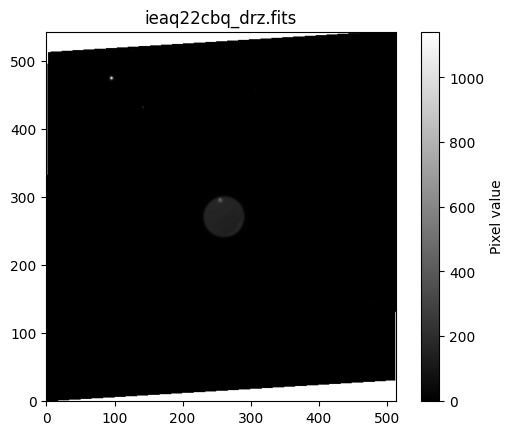

/.n--- ieaq22cgq_drz.fits ---


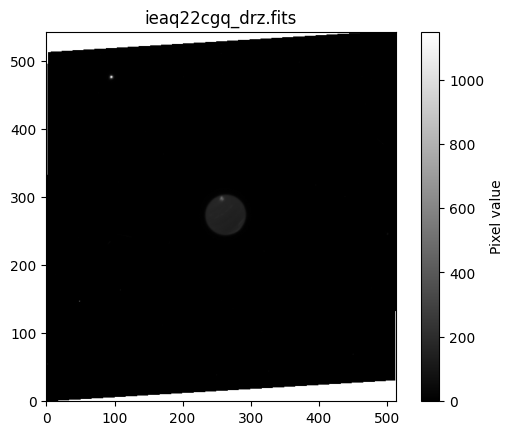

/.n--- ieaq27k5q_drz.fits ---


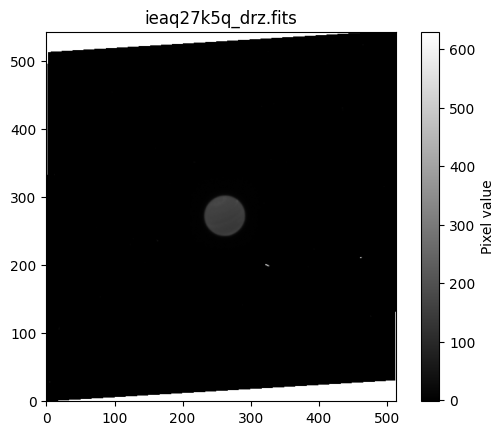

/.n--- ieaq26j5q_drz.fits ---


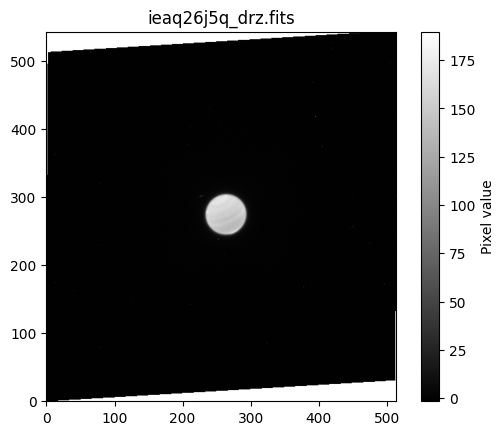

In [43]:
folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/drz/UVIS2 F845M"
show_all_fits_images(folder)